# 02 - Exploratory Data Analysis

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook explores structure, distributions, and early signals of the 174,000 swing observations collected in `01_data_pipeline.ipynb`.  
<br>
No formal analysis or conclusions are drawn here, the goal is **better understanding and literacy of our pulled and sampled data**. Observations noted here directly inform further constructions and formal analytical layers following.



___
## 1. Data Loading & Cleaning Decisions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


# Load pooled sample
df = pd.read_csv(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\data\final\mlb_pooled_sample.csv")

print("Shape: ", df.shape)
print("\nColumn Names: ")
print(df.columns.tolist())
print("\nData Types: ")
print(df.dtypes)

df.head()

Shape:  (174000, 12)

Column Names: 
['season', 'game_date', 'home_team', 'pitch_type', 'pitch_category', 'description', 'swing_outcome', 'launch_speed', 'launch_angle', 'stand', 'p_throws', 'release_speed']

Data Types: 
season              int64
game_date             str
home_team             str
pitch_type            str
pitch_category        str
description           str
swing_outcome         str
launch_speed      float64
launch_angle      float64
stand                 str
p_throws              str
release_speed     float64
dtype: object


,season,game_date,home_team,pitch_type,pitch_category,description,swing_outcome,launch_speed,launch_angle,stand,p_throws,release_speed
0,2023,2023-08-09,AZ,FC,Fastball,hit_into_play,in_play,92.1,43.0,L,R,92.6
1,2023,2023-09-20,AZ,KC,Breaking,hit_into_play,in_play,93.0,22.0,L,R,85.3
2,2023,2023-07-07,AZ,FF,Fastball,foul,foul,84.8,31.0,R,R,94.5
3,2023,2023-07-06,AZ,CU,Breaking,foul,foul,67.0,59.0,L,R,81.9
4,2023,2023-08-21,AZ,FS,Offspeed,swinging_strike_blocked,whiff,NaN,NaN,L,R,86.0


In [8]:
# Change game_date from string --> datetime variable
df['game_date'] = pd.to_datetime(df['game_date'])


# Remove knuckleballs and Statcast unclassified pitches
# KN (n=115) behaves unlike any other pitch type — exclusion justified
# NaN pitch_category (n=748) could not be classified by Statcast — excluded

df = df[df['pitch_category'].notna()].reset_index(drop=True)
working_set = len(df)

#
print(f"Working dataset:     {working_set:,} swings")

Working dataset:     173,137 swings


## Setting Up SQLite Database

In [9]:
import sqlite3
from pathlib import Path

# Connect to database
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")
DB_PATH.parent.mkdir(parents = True, exist_ok = True)

conn = sqlite3.connect(DB_PATH)

# Write working dataset over to SQLite
df.to_sql('swings', conn, if_exists = 'replace', index = False)

print(f"Database created at: {DB_PATH}")
print(f"Table 'swings' written: {len(df):,} rows")



Database created at: C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db
Table 'swings' written: 173,137 rows


___
## 2. Sample Integrity Check (SQL)

Confirming that all 29 parks intended for sample are present and each contribute close to 6,000 swings.

In [13]:
query = """
    SELECT
        home_team,
        COUNT(*) as swing_count
    FROM swings
    GROUP BY home_team
    ORDER BY swing_count DESC
"""

ballpark_counts = pd.read_sql_query(query, conn)

print(f"Parks present: {len(ballpark_counts)} / 29")
print(f"\nSwings per park:")
print(ballpark_counts.to_string(index=False))
print(f"\nMin:  {ballpark_counts['swing_count'].min():,}")
print(f"Max:  {ballpark_counts['swing_count'].max():,}")
print(f"Mean: {ballpark_counts['swing_count'].mean():,.2f}")


# Listing parks that came in < 6,000


Parks present: 29 / 29

Swings per park:
home_team  swing_count
      PIT         6000
      MIN         6000
      TOR         5999
      NYY         5999
      NYM         5998
      MIA         5998
       AZ         5996
      COL         5994
      PHI         5993
      STL         5992
      TEX         5990
      LAD         5988
       TB         5981
      HOU         5978
      LAA         5973
      CLE         5970
       SF         5966
      DET         5965
      CWS         5964
      BAL         5957
      BOS         5955
      CIN         5953
      WSH         5948
       SD         5948
       KC         5948
      SEA         5944
      ATL         5927
      CHC         5910
      MIL         5903

Min:  5,903
Max:  6,000
Mean: 5,970.24



**All 29 parks are present (obviously) and within 97 swings of the 6,000 swing sample target - going to be a variance of less than 2 %.**
<br><br>
Slight shortfallings at certain parks are due to removing knuckleballs (*n=115*) and 'unclassified' pitches (*n = 748*) while cleaning.  We can confirm sample integrity across all measured parks.

___
## 3. Pitch Category Distribution

League-wide pitch category distribution:
pitch_category  count   pct
      Fastball  96689 55.85
      Breaking  51650 29.83
      Offspeed  24798 14.32


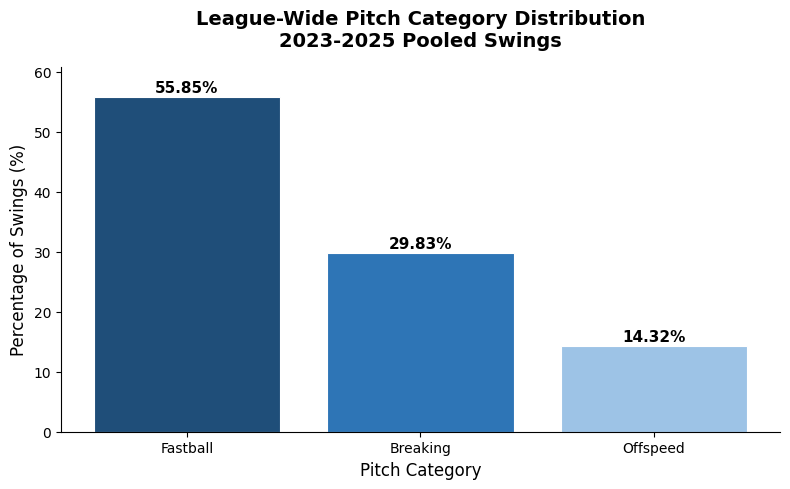

In [19]:
query = """
    SELECT
        pitch_category,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM swings
    GROUP BY pitch_category
    ORDER BY count DESC
"""

pitch_distrib = pd.read_sql_query(query, conn)
print("League-wide pitch category distribution:")
print(pitch_distrib.to_string(index=False))


# Visualization
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#1F4E79', '#2E75B6', '#9DC3E6']

ax.bar(pitch_distrib['pitch_category'], 
       pitch_distrib['pct'],
       color=colors,
       edgecolor='white',
       linewidth=0.8)

ax.set_title('League-Wide Pitch Category Distribution\n2023-2025 Pooled Swings', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pitch Category', fontsize=12)
ax.set_ylabel('Percentage of Swings (%)', fontsize=12)

for bar, pct in zip(ax.patches, pitch_distrib['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{pct}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, pitch_distrib['pct'].max() + 5)
sns.despine()
plt.tight_layout()
plt.show()

Fastballs dominate swing events across the 2023-2025 sample, accounting for largest share at **55.85%**. Breaking balls represent the second most common swing event (**29.83%**), with Offspeed pitches considerably trailing (**14.32%**).
<br><br>
The league-wide baseline will serve as a strong point of reference distribution when examining pitch frequencies at the individual park level.
<br><br>
<br><br>
*We can also take a closer look at individual pitch types below ...*

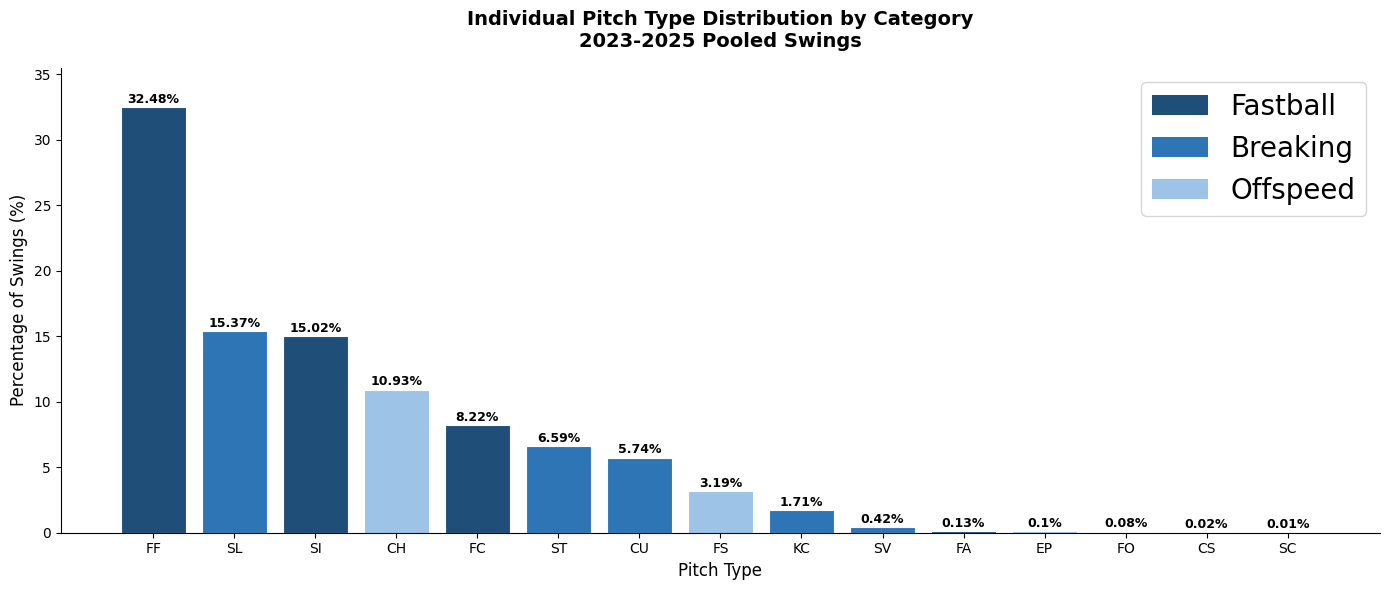

Pitch Type Key:
------------------------------
  FF:  Four-Seam Fastball
  SL:  Slider
  SI:  Sinker
  CH:  Changeup
  FC:  Cutter
  ST:  Sweeper
  CU:  Curveball
  FS:  Splitter
  KC:  Knuckle Curve
  SV:  Slurve
  FA:  Fastball
  EP:  Eephus
  FO:  Forkball
  CS:  Slow Curve
  SC:  Screwball
------------------------------


In [25]:
query = """
    SELECT
        pitch_type,
        pitch_category,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM swings
    GROUP BY pitch_type, pitch_category
    ORDER BY count DESC
"""

pitch_type_dist = pd.read_sql_query(query, conn)

# Map category colors
color_map = {
    'Fastball': '#1F4E79',
    'Breaking': '#2E75B6',
    'Offspeed': '#9DC3E6'
}

colors = pitch_type_dist['pitch_category'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(pitch_type_dist['pitch_type'],
              pitch_type_dist['pct'],
              color=colors,
              edgecolor='white',
              linewidth=0.8)

# Percentage labels
for bar, pct in zip(ax.patches, pitch_type_dist['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{pct}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1F4E79', label='Fastball'),
    Patch(facecolor='#2E75B6', label='Breaking'),
    Patch(facecolor='#9DC3E6', label='Offspeed')
]
ax.legend(handles=legend_elements, fontsize=20)

ax.set_title('Individual Pitch Type Distribution by Category\n2023-2025 Pooled Swings',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pitch Type', fontsize=12)
ax.set_ylabel('Percentage of Swings (%)', fontsize=12)
ax.set_ylim(0, pitch_type_dist['pct'].max() + 3)

sns.despine()
plt.tight_layout()
plt.show()

# Pitch type key — same order as chart (count descending)
pitch_names = {
    'FF': 'Four-Seam Fastball',
    'FC': 'Cutter',
    'SI': 'Sinker',
    'FA': 'Fastball',
    'FT': 'Two-Seam Fastball',
    'SF': 'Split-Finger Fastball',
    'SL': 'Slider',
    'ST': 'Sweeper',
    'CU': 'Curveball',
    'KC': 'Knuckle Curve',
    'SV': 'Slurve',
    'CH': 'Changeup',
    'FS': 'Splitter',
    'CS': 'Slow Curve',
    'EP': 'Eephus',
    'FO': 'Forkball',
    'SC': 'Screwball',
}

print("Pitch Type Key:")
print("-" * 30)
for code in pitch_type_dist['pitch_type'].values:
    if code in pitch_names:
        print(f"  {code}:  {pitch_names[code]}")
print("-" * 30)

___
## 4. Swing Outcome Distribution
<br><br>
Every observation in this sample is a swing.  The three mutually exclusive outcomes are:
- **Whiff**: swing and miss
- **Foul**: contact, ball does NOT enter play
- **In Play**: contact, ball enters the field of play

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from pathlib import Path


DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)


outcome_counts = (
    df.groupby("swing_outcome", as_index=False)
      .size()
      .rename(columns={"size": "count"})
)
outcome_counts["pct"] = outcome_counts["count"] / outcome_counts["count"].sum()
outcome_counts = outcome_counts.sort_values("pct", ascending=False).reset_index(drop=True)

print(f"Total swings: {len(df):,}\n")
print(outcome_counts.to_string(index=False))

Total swings: 173,137

swing_outcome  count      pct
         foul  65205 0.376609
      in_play  63777 0.368361
        whiff  44155 0.255029


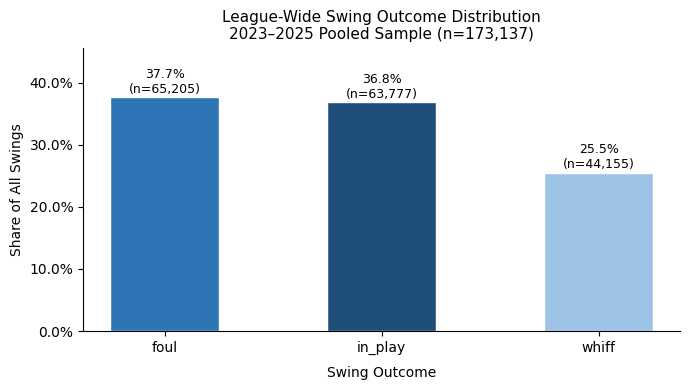

In [ ]:
OUTCOME_COLORS = {
    "in_play": "#1F4E79",
    "foul":    "#2E75B6",
    "whiff":   "#9DC3E6",
}

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    outcome_counts["swing_outcome"],
    outcome_counts["pct"],
    color=[OUTCOME_COLORS[o] for o in outcome_counts["swing_outcome"]],
    width=0.5,
    edgecolor="white",
)

for bar, (_, row) in zip(bars, outcome_counts.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{row['pct']:.1%}\n(n={row['count']:,})",
        ha="center", va="bottom", fontsize=9
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, outcome_counts["pct"].max() + 0.08)
ax.set_xlabel("Swing Outcome", labelpad=8)
ax.set_ylabel("Share of All Swings")
ax.set_title("League-Wide Swing Outcome Distribution\n2023-2025 Pooled Sample (n=173,137)", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

swing_outcome    foul in_play  whiff
pitch_category                      
Breaking        32.5%   34.9%  32.6%
Fastball        42.2%   37.6%  20.2%
Offspeed        30.8%   37.8%  31.5%


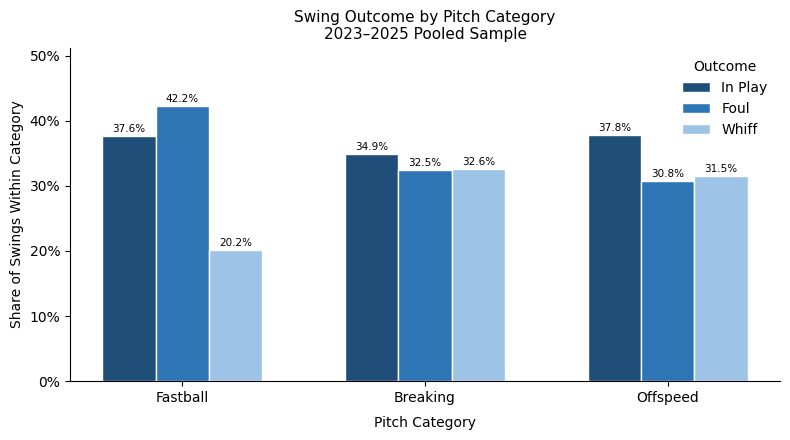

In [ ]:
# Outcome rates by pitch category
cat_outcome = (
    df.groupby(["pitch_category", "swing_outcome"])
      .size()
      .reset_index(name="n")
)
cat_total = df.groupby("pitch_category").size().reset_index(name="total")
cat_outcome = cat_outcome.merge(cat_total, on="pitch_category")
cat_outcome["pct"] = cat_outcome["n"] / cat_outcome["total"]


print(cat_outcome.pivot(index="pitch_category", columns="swing_outcome", values="pct")
                 .map(lambda x: f"{x:.1%}")  # changed applymap → map
                 .to_string())

CAT_ORDER    = ["Fastball", "Breaking", "Offspeed"]
OUTCOME_ORDER = ["in_play", "foul", "whiff"]

pivot = cat_outcome.pivot(index="pitch_category", columns="swing_outcome", values="pct")
pivot = pivot.loc[CAT_ORDER, OUTCOME_ORDER]

x = np.arange(len(CAT_ORDER))
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, outcome in enumerate(OUTCOME_ORDER):
    bars = ax.bar(
        x + (i - 1) * width,
        pivot[outcome],
        width=width,
        label=outcome.replace("_", " ").title(),
        color=OUTCOME_COLORS[outcome],
        edgecolor="white",
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f"{bar.get_height():.1%}",
            ha="center", va="bottom", fontsize=7.5
        )

ax.set_xticks(x)
ax.set_xticklabels(CAT_ORDER)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, pivot.values.max() + 0.09)
ax.set_xlabel("Pitch Category", labelpad=8)
ax.set_ylabel("Share of Swings Within Category")
ax.set_title("Swing Outcome by Pitch Category\n2023-2025 Pooled Sample", fontsize=11)
ax.legend(title="Outcome", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()